In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())

Project root: /home/syed/GWU/Spring 2026/Big Data Analytics/renewable-energy-forecasting-pipeline
Current working directory: /home/syed/GWU/Spring 2026/Big Data Analytics/renewable-energy-forecasting-pipeline


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from src.ingestion.station_metadata_loader import load_station_metadata
from src.ingestion.station_filter import (
    filter_us_stations,
    remove_invalid_coordinates,
    filter_excluded_states,
    filter_contiguous_us_geography,
    filter_active_stations,
    build_station_master,
    filter_known_states
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)

In [3]:
METADATA_PATH = "data/raw/noaa_metadata/isd-history.csv"

stations_df = load_station_metadata(METADATA_PATH)

print(f"Loaded metadata rows: {len(stations_df):,}")
stations_df.head()

Loaded metadata rows: 28,474


,station_id,station_name,country_code,state,latitude,longitude,elevation_m,begin_date,end_date,begin_year,end_year
0,00701899999,WXPOD 7018,NaN,,0.00,0.000,7018.0,2011-03-09,2013-07-30,2011,2013
1,00702699999,WXPOD 7026,AF,,0.00,0.000,7026.0,2012-07-13,2017-08-22,2012,2017
2,00707099999,WXPOD 7070,AF,,0.00,0.000,7070.0,2014-09-23,2015-09-26,2014,2015
3,00826099999,WXPOD8270,NaN,,0.00,0.000,0.0,2005-01-01,2012-07-31,2005,2012
4,00826899999,WXPOD8278,AF,,32.95,65.567,1156.7,2010-05-19,2012-03-23,2010,2012


In [4]:
print("Columns:")
print(stations_df.columns.tolist())

Columns:
['station_id', 'station_name', 'country_code', 'state', 'latitude', 'longitude', 'elevation_m', 'begin_date', 'end_date', 'begin_year', 'end_year']


In [5]:
us_df = filter_us_stations(stations_df)
coords_df = remove_invalid_coordinates(us_df)
states_df = filter_excluded_states(coords_df)
contiguous_df = filter_contiguous_us_geography(states_df)
known_state_df = filter_known_states(contiguous_df)
final_df = filter_active_stations(known_state_df)

summary_counts = pd.DataFrame(
    {
        "step": [
            "total_metadata_stations",
            "us_stations",
            "valid_coordinate_us_stations",
            "after_excluding_ak_hi_territories",
            "contiguous_us_stations",
            "final_station_master",
        ],
        "count": [
            len(stations_df),
            len(us_df),
            len(coords_df),
            len(states_df),
            len(contiguous_df),
            len(final_df),
        ],
    }
)

summary_counts

,step,count
0,total_metadata_stations,28474
1,us_stations,7074
2,valid_coordinate_us_stations,7052
3,after_excluding_ak_hi_territories,6432
4,contiguous_us_stations,6225
5,final_station_master,5830


In [6]:
station_master_df = build_station_master(stations_df)

print("Stepwise final count:", len(final_df))
print("build_station_master count:", len(station_master_df))
print("Counts match:", len(final_df) == len(station_master_df))

Stepwise final count: 5830
build_station_master count: 5830
Counts match: True


In [7]:
station_master_df.head(10)

,station_id,station_name,country_code,state,latitude,longitude,elevation_m,begin_date,end_date,begin_year,end_year
0,69001499999,C STN WHITE SANDS,US,NM,32.350,-106.367,1224.0,1987-01-01,1991-06-11,1987,1991
1,69002093218,JOLON HUNTER LIGGETT MIL RES,US,CA,36.000,-121.233,317.0,1964-07-15,1997-04-01,1964,1997
2,69002099999,JOLON HUNTER LIGGETT MIL RES,US,CA,36.000,-121.233,317.0,2003-07-02,2003-08-01,2003,2003
3,69007093217,FRITZSCHE AAF,US,CA,36.683,-121.767,43.0,1960-04-04,1993-08-31,1960,1993
4,69009099999,HURLBURT FLD/EXERCIS,US,FL,30.433,-86.717,3.0,2008-10-10,2008-10-17,2008,2008
5,69011099999,SELFRIDGE ANGB/TRAIN,US,MI,42.608,-82.835,177.0,1943-06-14,1992-05-07,1943,1992
6,69014093101,EL TORO MCAS,US,CA,33.667,-117.733,116.7,1989-01-01,1997-12-31,1989,1997
7,69015093121,TWENTY NINE PALMS,US,CA,34.294,-116.147,610.5,1990-01-02,2025-08-25,1990,2025
8,69015099999,TWENTYNINE PALMS,US,CA,34.300,-116.167,626.0,1989-11-15,1989-12-29,1989,1989
9,69017099999,IND SPRNG RANGE 63,US,NV,36.533,-115.567,972.0,1980-05-14,1997-12-31,1980,1997


In [8]:
station_master_df[["latitude", "longitude"]].describe()

,latitude,longitude
count,5830.000000,5830.000000
mean,37.956841,-94.615986
std,5.645937,14.780028
min,24.550000,-124.733000
25%,33.714250,-105.086750
50%,38.261000,-92.717500
75%,42.217000,-82.715000
max,49.318000,-66.550000


In [9]:
state_counts = (
    station_master_df["state"]
    .fillna("")
    .value_counts()
    .rename_axis("state")
    .reset_index(name="station_count")
)

state_counts.head(25)

,state,station_count
0,CA,492
1,TX,490
2,FL,301
3,MI,227
4,MN,204
5,NC,199
6,LA,185
7,CO,161
8,WA,155
9,GA,150


In [10]:
station_master_df[["begin_year", "end_year"]].describe()

,begin_year,end_year
count,5830.000000,5830.000000
mean,1987.183705,2005.285763
std,23.687116,22.408809
min,1931.000000,1936.000000
25%,1973.000000,1997.000000
50%,2000.000000,2008.000000
75%,2006.000000,2025.000000
max,2025.000000,2025.000000


In [11]:
print("Earliest begin year:", int(station_master_df["begin_year"].min()))
print("Latest end year:", int(station_master_df["end_year"].max()))

Earliest begin year: 1931
Latest end year: 2025


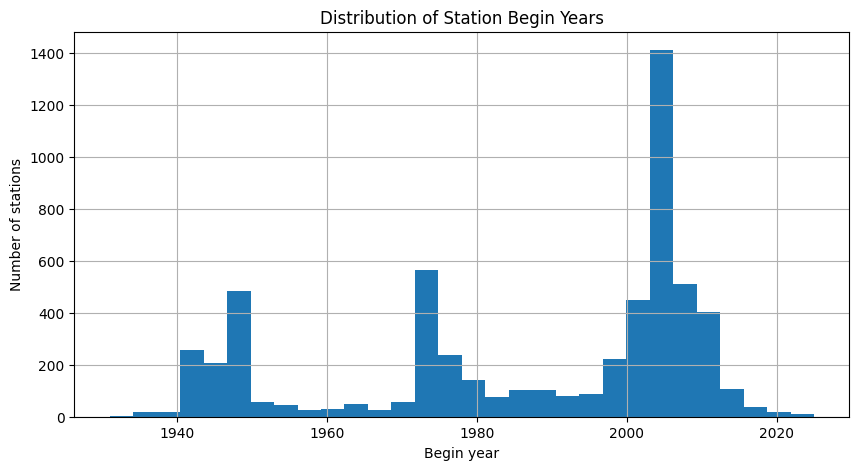

In [12]:
plt.figure(figsize=(10, 5))
station_master_df["begin_year"].dropna().astype(int).hist(bins=30)
plt.title("Distribution of Station Begin Years")
plt.xlabel("Begin year")
plt.ylabel("Number of stations")
plt.show()

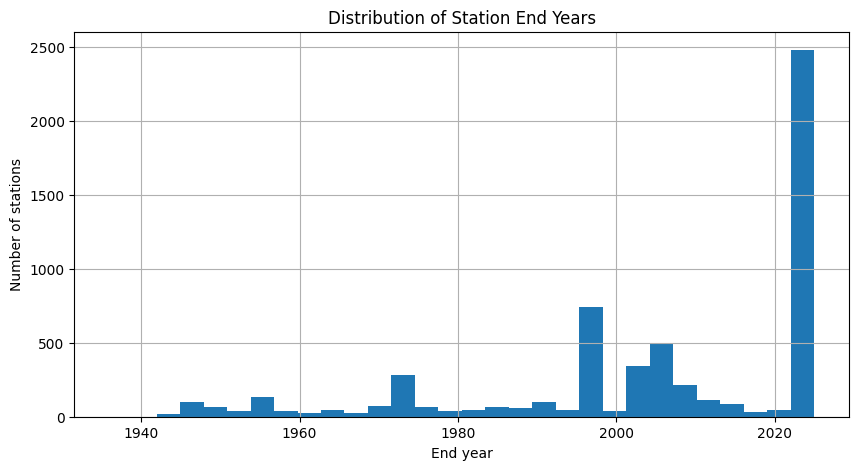

In [13]:
plt.figure(figsize=(10, 5))
station_master_df["end_year"].dropna().astype(int).hist(bins=30)
plt.title("Distribution of Station End Years")
plt.xlabel("End year")
plt.ylabel("Number of stations")
plt.show()

In [14]:
PROJECT_START_YEAR = 1995
PROJECT_END_YEAR = 2025

active_project_window_df = station_master_df[
    (station_master_df["begin_year"] <= PROJECT_END_YEAR) &
    (station_master_df["end_year"] >= PROJECT_START_YEAR)
].copy()

print(f"Stations overlapping {PROJECT_START_YEAR}–{PROJECT_END_YEAR}: {len(active_project_window_df):,}")
active_project_window_df.head()

Stations overlapping 1995–2025: 4,600


,station_id,station_name,country_code,state,latitude,longitude,elevation_m,begin_date,end_date,begin_year,end_year
1,69002093218,JOLON HUNTER LIGGETT MIL RES,US,CA,36.000,-121.233,317.0,1964-07-15,1997-04-01,1964,1997
2,69002099999,JOLON HUNTER LIGGETT MIL RES,US,CA,36.000,-121.233,317.0,2003-07-02,2003-08-01,2003,2003
4,69009099999,HURLBURT FLD/EXERCIS,US,FL,30.433,-86.717,3.0,2008-10-10,2008-10-17,2008,2008
6,69014093101,EL TORO MCAS,US,CA,33.667,-117.733,116.7,1989-01-01,1997-12-31,1989,1997
7,69015093121,TWENTY NINE PALMS,US,CA,34.294,-116.147,610.5,1990-01-02,2025-08-25,1990,2025


In [15]:
final_df.head(10)

,station_id,station_name,country_code,state,latitude,longitude,elevation_m,begin_date,end_date,begin_year,end_year
13914,69001499999,C STN WHITE SANDS,US,NM,32.350,-106.367,1224.0,1987-01-01,1991-06-11,1987,1991
13915,69002093218,JOLON HUNTER LIGGETT MIL RES,US,CA,36.000,-121.233,317.0,1964-07-15,1997-04-01,1964,1997
13916,69002099999,JOLON HUNTER LIGGETT MIL RES,US,CA,36.000,-121.233,317.0,2003-07-02,2003-08-01,2003,2003
13917,69007093217,FRITZSCHE AAF,US,CA,36.683,-121.767,43.0,1960-04-04,1993-08-31,1960,1993
13920,69009099999,HURLBURT FLD/EXERCIS,US,FL,30.433,-86.717,3.0,2008-10-10,2008-10-17,2008,2008
13922,69011099999,SELFRIDGE ANGB/TRAIN,US,MI,42.608,-82.835,177.0,1943-06-14,1992-05-07,1943,1992
13923,69014093101,EL TORO MCAS,US,CA,33.667,-117.733,116.7,1989-01-01,1997-12-31,1989,1997
13924,69015093121,TWENTY NINE PALMS,US,CA,34.294,-116.147,610.5,1990-01-02,2025-08-25,1990,2025
13925,69015099999,TWENTYNINE PALMS,US,CA,34.300,-116.167,626.0,1989-11-15,1989-12-29,1989,1989
13928,69017099999,IND SPRNG RANGE 63,US,NV,36.533,-115.567,972.0,1980-05-14,1997-12-31,1980,1997


In [16]:
OUTPUT_PATH = Path("outputs/sample_runs/station_master_contiguous_us.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

station_master_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved station master to: {OUTPUT_PATH}")

Saved station master to: outputs/sample_runs/station_master_contiguous_us.csv


In [17]:
selected_states = ["CA", "TX", "MN", "FL"]

selected_state_counts = (
    station_master_df[station_master_df["state"].isin(selected_states)]["state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="station_count")
)

selected_state_counts

,state,station_count
0,CA,492
1,TX,490
2,FL,301
3,MN,204


In [18]:
project_start_year = 1995
project_end_year = 2025

selected_project_window_df = station_master_df[
    (station_master_df["state"].isin(selected_states)) &
    (station_master_df["begin_year"] <= project_end_year) &
    (station_master_df["end_year"] >= project_start_year)
].copy()

print(f"Stations in selected states overlapping {project_start_year}–{project_end_year}: {len(selected_project_window_df):,}")
selected_project_window_df.head()

Stations in selected states overlapping 1995–2025: 1,162


,station_id,station_name,country_code,state,latitude,longitude,elevation_m,begin_date,end_date,begin_year,end_year
1,69002093218,JOLON HUNTER LIGGETT MIL RES,US,CA,36.000,-121.233,317.0,1964-07-15,1997-04-01,1964,1997
2,69002099999,JOLON HUNTER LIGGETT MIL RES,US,CA,36.000,-121.233,317.0,2003-07-02,2003-08-01,2003,2003
4,69009099999,HURLBURT FLD/EXERCIS,US,FL,30.433,-86.717,3.0,2008-10-10,2008-10-17,2008,2008
6,69014093101,EL TORO MCAS,US,CA,33.667,-117.733,116.7,1989-01-01,1997-12-31,1989,1997
7,69015093121,TWENTY NINE PALMS,US,CA,34.294,-116.147,610.5,1990-01-02,2025-08-25,1990,2025


In [19]:
dev_start_year = 2018
dev_end_year = 2020

selected_dev_window_df = station_master_df[
    (station_master_df["state"].isin(selected_states)) &
    (station_master_df["begin_year"] <= dev_end_year) &
    (station_master_df["end_year"] >= dev_start_year)
].copy()

print(f"Stations in selected states overlapping {dev_start_year}–{dev_end_year}: {len(selected_dev_window_df):,}")

Stations in selected states overlapping 2018–2020: 630


In [20]:
target_stations = 150

dev_subset_plan = {
    "selected_states": selected_states,
    "dev_years": [2018, 2019, 2020],
    "target_station_count": target_stations,
    "project_scope_at_scale": "contiguous_us_1995_2025",
    "local_dev_scope": "representative_subset",
    "primary_target": "wind",
    "secondary_fields": ["TMP", "DEW", "SLP", "VIS", "CIG"],
    "out_of_scope": ["solar", "sparse_optional_fields"],
}

dev_subset_plan

{'selected_states': ['CA', 'TX', 'MN', 'FL'],
 'dev_years': [2018, 2019, 2020],
 'target_station_count': 150,
 'project_scope_at_scale': 'contiguous_us_1995_2025',
 'local_dev_scope': 'representative_subset',
 'primary_target': 'wind',
 'secondary_fields': ['TMP', 'DEW', 'SLP', 'VIS', 'CIG'],
 'out_of_scope': ['solar', 'sparse_optional_fields']}